# EEG Trigger Press · Pipeline v2
## Improved Features · CSP / xDAWN Spatial Filters · Gradient Boosting

All pipeline improvement recommendations implemented:

| # | Fix | Implementation |
|---|---|---|
| 1 | Fix LDA evaluation bug | `loto_eval` always populates from the correct model |
| 2 | Optimise AP / positive-class recall | Optuna objective = `average_precision_score` |
| 3 | Increase temporal window to 3 s | `T_MAX = 3.0 × FS_EFF` |
| 4 | Temporal + frequency features | `temporal_features`, `freq_features` (no leakage) |
| 5 | CSP + RLDA | `mne.decoding.CSP` inside LOTO |
| 6 | xDAWN + RLDA | Custom numpy implementation |
| 7 | Gradient boosting | LightGBM with Optuna AP objective |
| 8 | Threshold inside CV | `roc_curve` on training fold → no test leakage |
| 9 | No normalisation leakage | All scalers / filters fit on training fold only |


## 1 · Imports & Setup

In [17]:
import warnings

warnings.filterwarnings("ignore")
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy.linalg import eigh
from scipy.signal import welch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from mne.decoding import CSP

    HAS_CSP = True
except ImportError:
    HAS_CSP = False

try:
    import lightgbm as lgb

    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import xgboost as xgb

    HAS_XGB = True
except ImportError:
    HAS_XGB = False

sys.path.insert(0, "..")
from src.postproc import event_detection_metrics
from src.preprocessing import build_windows, load_trial, make_horizon_labels

optuna.logging.set_verbosity(optuna.logging.WARNING)

DARK, CARD, EDGE = "#0a0e17", "#111827", "#1f2937"
TEAL, CORAL, GOLD, WHITE, LIME = "#00e5cc", "#ff4f5e", "#ffc947", "#f0f4ff", "#a8ff3e"
PURPLE, ORANGE = "#c084fc", "#f97316"
PALETTE = [TEAL, CORAL, GOLD, LIME, PURPLE, ORANGE, WHITE]

print("Imports OK")
print(f"  CSP={HAS_CSP}  LightGBM={HAS_LGB}  XGBoost={HAS_XGB}")

Imports OK
  CSP=True  LightGBM=True  XGBoost=True


## 2 · Config

In [2]:
SUBJECT = 9
TACHE = "spt"
ALL_TRIALS = list(range(10))
DATA_PATH = f"../data/subject{SUBJECT}/"
FS = 250
DECIM = 4  # FS_EFF=62 Hz — better freq resolution than DECIM=6
FS_EFF = FS // DECIM
LP, HP = 0.5, 8.0
HORIZON = int(1.0 * FS_EFF)  # 1000 ms anticipatory window
TARGET = "button"

T_MAX_S = 3.0
T_MAX = int(T_MAX_S * FS_EFF)  # 3 s — captures full Bereitschaftspotential onset

MIN_SPEC = 0.80  # specificity floor for threshold selection
SMOOTH_WIN_S = 0.3  # 300 ms causal smoothing
SMOOTH_WIN = max(1, int(SMOOTH_WIN_S * FS_EFF))

N_CSP = 4  # CSP components (4 = 2 per class extremes)
N_XDAWN = 4  # xDAWN components

N_OPTUNA = 20
TRAIN_CAP = 12_000  # cap samples per training fold for speed
SEED = 42

print(f"FS_EFF    : {FS_EFF} Hz  (DECIM={DECIM})")
print(f"Band-pass : {LP}–{HP} Hz")
print(f"HORIZON   : {HORIZON} samples  ({HORIZON/FS_EFF*1000:.0f} ms)")
print(f"T_MAX     : {T_MAX} samples  ({T_MAX/FS_EFF*1000:.0f} ms)")
print(f"SMOOTH_WIN: {SMOOTH_WIN} samples  ({SMOOTH_WIN/FS_EFF*1000:.0f} ms)")

FS_EFF    : 62 Hz  (DECIM=4)
Band-pass : 0.5–8.0 Hz
HORIZON   : 62 samples  (1000 ms)
T_MAX     : 186 samples  (3000 ms)
SMOOTH_WIN: 18 samples  (290 ms)


## 3 · Load & Filter Trials

In [3]:
print("Loading all trials (CAR + trial_zscore + bandpass) …")
raw_data = {}
EEG_COLS = None

for t in ALL_TRIALS:
    df, cols = load_trial(
        SUBJECT,
        TACHE,
        t,
        DATA_PATH,
        eeg_cols=EEG_COLS,
        lp=LP,
        hp=HP,
        decimate=DECIM,
        car=True,
        trial_zscore=True,
    )
    if EEG_COLS is None:
        EEG_COLS = cols
    X_t = df[EEG_COLS].values.astype(np.float32)
    y_t = make_horizon_labels(df[TARGET].values.astype(int), HORIZON)
    y_mom_t = df[TARGET].values.astype(np.int8)
    raw_data[t] = (X_t, y_t, y_mom_t)
    n_pos = int(y_t.sum())
    print(
        f"  trial {t:2d}: {len(df):6,} samples  press={n_pos:5,} ({n_pos/len(df)*100:.1f}%)"
    )

N_CH = len(EEG_COLS)
print(f"\n{N_CH} channels: {EEG_COLS}")

Loading all trials (CAR + trial_zscore + bandpass) …
Setting up band-pass filter from 0.5 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 1651 samples (6.604 s)

  trial  0:  5,085 samples  press=1,443 (28.4%)
Setting up band-pass filter from 0.5 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper p

## 4 · Feature Engineering Functions

Two feature families computed on unnormalized windows (trial-z-scored but not per-window normalised) to preserve MRCP amplitude information:
- **Temporal**: mean, std, slope, minimum value, position of minimum, RMS energy
- **Frequency**: delta power (0.5–4 Hz), theta power (4–8 Hz), spectral entropy

xDAWN spatial filter is implemented from scratch (no dependency on `mne.preprocessing`).

In [4]:
def temporal_features(X3d: np.ndarray) -> np.ndarray:
    """(N, T, C) -> (N, C*6): mean, std, slope, min_val, argmin_norm, rms."""
    N, T, C = X3d.shape
    out = np.zeros((N, C * 6), dtype=np.float32)
    t_idx = np.arange(T, dtype=np.float64)
    t_c = t_idx - t_idx.mean()
    t_var = (t_c**2).sum() + 1e-12
    for c in range(C):
        x = X3d[:, :, c].astype(np.float64)  # (N, T)
        out[:, c * 6 + 0] = x.mean(axis=1)
        out[:, c * 6 + 1] = x.std(axis=1)
        out[:, c * 6 + 2] = (x * t_c).sum(axis=1) / t_var  # slope
        out[:, c * 6 + 3] = x.min(axis=1)
        out[:, c * 6 + 4] = x.argmin(axis=1) / T  # normalised position of minimum
        out[:, c * 6 + 5] = np.sqrt((x**2).mean(axis=1))  # RMS
    return out


def freq_features(X3d: np.ndarray, fs: float) -> np.ndarray:
    """(N, T, C) -> (N, C*3): delta power, theta power, spectral entropy."""
    N, T, C = X3d.shape
    out = np.zeros((N, C * 3), dtype=np.float32)
    nperseg = min(T, 64)
    for i in range(N):
        freqs, psd = welch(X3d[i].T, fs=fs, nperseg=nperseg)  # (C, F)
        df_f = freqs[1] - freqs[0] if len(freqs) > 1 else 1.0
        m_d = (freqs >= 0.5) & (freqs <= 4.0)
        m_t = (freqs >= 4.0) & (freqs <= 8.0)
        m_all = freqs > 0
        dp = psd[:, m_d].sum(axis=1) * df_f  # (C,)
        tp = psd[:, m_t].sum(axis=1) * df_f
        pn = psd[:, m_all] / (psd[:, m_all].sum(axis=1, keepdims=True) + 1e-12)
        se = -(pn * np.log(pn + 1e-12)).sum(axis=1)
        out[i, 0::3] = dp
        out[i, 1::3] = tp
        out[i, 2::3] = se
    return out


def build_eng_features(X3d: np.ndarray, fs: float) -> np.ndarray:
    """Concatenate temporal + frequency features. (N,T,C) -> (N, C*9)."""
    return np.concatenate([temporal_features(X3d), freq_features(X3d, fs)], axis=1)


# ── Custom xDAWN (numpy-only) ─────────────────────────────────────────────────
def fit_xdawn(X3d_ct: np.ndarray, y: np.ndarray, n_components: int) -> np.ndarray:
    """
    xDAWN spatial filter via generalised eigenvalue decomposition.
    X3d_ct: (N, C, T) — channels-first
    Returns W: (C, n_components)
    """
    N, C, T = X3d_ct.shape
    X64 = X3d_ct.astype(np.float64)
    M = X64[y == 1].mean(axis=0)  # (C, T) mean MRCP
    Ss = (M @ M.T) / T  # signal covariance
    covs = np.einsum("nct,ndt->ncd", X64, X64) / T  # (N, C, C)
    Sd = covs.mean(axis=0) + 1e-6 * np.eye(C)  # data covariance
    eigvals, eigvecs = eigh(Ss, Sd)
    idx = np.argsort(eigvals)[::-1]
    return eigvecs[:, idx[:n_components]].astype(np.float32)  # (C, k)


def apply_xdawn(X3d_ct: np.ndarray, W: np.ndarray) -> np.ndarray:
    """(N, C, T) x (C, k) -> (N, k, T)."""
    return np.einsum("nct,ck->nkt", X3d_ct, W)


print("Feature functions defined.")
print(f"  Temporal features : C×6 = {N_CH*6}")
print(f"  Frequency features: C×3 = {N_CH*3}")
print(f"  Combined          : C×9 = {N_CH*9}")

Feature functions defined.
  Temporal features : C×6 = 96
  Frequency features: C×3 = 48
  Combined          : C×9 = 144


## 5 · Pre-compute Windows at T_MAX

In [5]:
print(f"Pre-computing windows at T_MAX={T_MAX} ({T_MAX/FS_EFF*1000:.0f} ms) …")
_X, _y, _ymom, _tid = [], [], [], []

for t in ALL_TRIALS:
    X_t, y_t, y_mom_t = raw_data[t]
    Xw, yw = build_windows(X_t, y_t, T_MAX, per_window_norm=False)
    y_mom_w = y_mom_t[T_MAX:][: len(yw)]
    n = min(len(yw), len(y_mom_w))
    _X.append(Xw[:n].reshape(-1, T_MAX, N_CH))
    _y.append(yw[:n])
    _ymom.append(y_mom_w[:n])
    _tid.append(np.full(n, t, dtype=np.int32))

X_max = np.concatenate(_X)  # (M, T_MAX, C)  — unnormalised, trial-z-scored
y_all = np.concatenate(_y)
y_mom = np.concatenate(_ymom)
tid_all = np.concatenate(_tid)
del _X, _y, _ymom, _tid

n_pos = int(y_all.sum())
print(f"  shape={X_max.shape}  memory={X_max.nbytes/1e9:.2f} GB")
print(f"  windows={len(y_all):,}  press={n_pos:,} ({n_pos/len(y_all)*100:.1f}%)")


def get_windows_norm(T: int) -> np.ndarray:
    """Slice T samples + per-window z-score. Returns (M, T, C) float32."""
    X = X_max[:, T_MAX - T :, :].copy()
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-8
    return ((X - mu) / sd).astype(np.float32)


print(
    "\nPre-computing engineered feature matrix (uses X_max, NOT per-window normalised) …"
)
X_eng = build_eng_features(X_max, FS_EFF)  # (M, C*9)
print(f"  X_eng shape: {X_eng.shape}")

Pre-computing windows at T_MAX=186 (3000 ms) …
  shape=(40484, 186, 16)  memory=0.48 GB
  windows=40,484  press=22,828 (56.4%)

Pre-computing engineered feature matrix (uses X_max, NOT per-window normalised) …
  X_eng shape: (40484, 144)


## 6 · Shared Utilities

In [6]:
def subsample(X, y, n, seed):
    """Random subsample capped at n (natural class ratio preserved)."""
    rng = np.random.default_rng(seed)
    n = min(n, len(y))
    idx = np.sort(rng.choice(len(y), n, replace=False))
    return X[idx], y[idx]


def smooth_scores(scores, window=SMOOTH_WIN):
    if window <= 1:
        return scores.copy()
    return (
        pd.Series(scores)
        .rolling(window, min_periods=1)
        .mean()
        .values.astype(np.float32)
    )


def thresh_at_spec(fpr, tpr, thresholds, min_spec=MIN_SPEC):
    """Threshold that maximises TPR subject to specificity ≥ min_spec."""
    valid = (1 - fpr) >= min_spec
    if valid.any():
        return float(thresholds[np.argmax(tpr[valid])])
    return float(thresholds[np.argmax(tpr - fpr)])


def loto_eval(
    model_fn, X_input, y, tid, y_mom_arr, label, transform_fn=None, do_smooth=True
):
    """
    Full LOTO cross-validation with threshold selected inside each training fold.

    Parameters
    ----------
    model_fn     : callable(X_tr, y_tr) -> fitted model
                   model must have predict_proba OR decision_function.
    X_input      : (N, D) feature matrix  OR  (N, T, C) 3-D windows
    transform_fn : optional callable(X_tr, y_tr, X_te) -> (X_tr_feat, X_te_feat)
                   fitted on training fold, applied to both.
                   Use for CSP / xDAWN which must be re-fitted per fold.
    """
    scores = np.zeros(len(y), dtype=np.float32)
    fold_results = []

    for test_trial in ALL_TRIALS:
        te = tid == test_trial
        tr = ~te
        X_te_raw, y_te = X_input[te], y[te]
        X_tr_raw, y_tr = X_input[tr], y[tr]

        if transform_fn is not None:
            X_tr_f, X_te_f = transform_fn(X_tr_raw, y_tr, X_te_raw)
        else:
            X_tr_f, X_te_f = X_tr_raw, X_te_raw

        model = model_fn(X_tr_f, y_tr)

        if hasattr(model, "predict_proba"):
            sc_tr = model.predict_proba(X_tr_f)[:, 1]
            sc_te = model.predict_proba(X_te_f)[:, 1]
        else:
            sc_tr = model.decision_function(X_tr_f)
            sc_te = model.decision_function(X_te_f)

        # Threshold chosen from training fold only — no test leakage
        fpr_tr, tpr_tr, thr_tr = roc_curve(y_tr, sc_tr)
        thresh = thresh_at_spec(fpr_tr, tpr_tr, thr_tr)

        scores[te] = sc_te.astype(np.float32)
        auc = roc_auc_score(y_te, sc_te)
        ap = average_precision_score(y_te, sc_te)
        fold_results.append(dict(trial=test_trial, auc=auc, ap=ap, thresh=thresh))

    # Per-trial smoothing
    scores_s = np.zeros_like(scores)
    for t in ALL_TRIALS:
        m = tid == t
        scores_s[m] = smooth_scores(scores[m]) if do_smooth else scores[m]

    thresh_final = float(np.mean([r["thresh"] for r in fold_results]))
    preds = (scores_s >= thresh_final).astype(int)

    auc_mean = float(np.mean([r["auc"] for r in fold_results]))
    auc_std = float(np.std([r["auc"] for r in fold_results]))
    ap_mean = float(np.mean([r["ap"] for r in fold_results]))
    ap_std = float(np.std([r["ap"] for r in fold_results]))

    y_mom_aligned = y_mom_arr[: len(scores_s)]
    evt = event_detection_metrics(
        scores_s, y_mom_aligned, threshold=thresh_final, horizon=HORIZON, fs_eff=FS_EFF
    )

    # Per-fold table
    print(f'\n{"="*62}')
    print(f"  {label}")
    print(f'{"="*62}')
    for r in fold_results:
        print(
            f"  trial {r['trial']:2d}  AUC={r['auc']:.4f}  AP={r['ap']:.4f}  thresh={r['thresh']:.3f}"
        )
    print(f'  {"-"*56}')
    print(f"  Mean AUC  : {auc_mean:.4f} ± {auc_std:.4f}")
    print(f"  Mean AP   : {ap_mean:.4f} ± {ap_std:.4f}")
    print(f"  Threshold : {thresh_final:.4f}  (mean of per-fold training thresholds)")
    print(
        f"  EvtSens   : {evt['event_sensitivity']:.3f}   FA/min={evt['fa_per_minute']:.1f}"
    )
    print(f"  Latency   : {evt.get('mean_latency_ms', 0):.1f} ms")

    return dict(
        label=label,
        scores=scores_s,
        auc=auc_mean,
        auc_std=auc_std,
        ap=ap_mean,
        ap_std=ap_std,
        thresh=thresh_final,
        preds=preds,
        evt=evt,
        fold_results=fold_results,
    )


print("Utilities defined.")

Utilities defined.


## 7 · Baseline RLDA (Bug-Fixed)

**Bug in v1**: `lda_probs_s` was populated from `svm_probs` instead of `lda_probs`,
making LDA smooth AUC identical to SVM and its event metrics meaningless.
`loto_eval` fixes this by construction — each model writes only to its own score array.

T is swept using AP (not AUC) on alternating folds to find the optimal window length.

In [7]:
T_candidates = list(range(max(4, FS_EFF // 8), T_MAX + 1, max(1, T_MAX // 20)))
print(
    f"Sweeping T over {len(T_candidates)} values: {T_candidates[0]}–{T_candidates[-1]} samples …"
)

best_T_lda, best_ap_lda = T_MAX, 0.0
for T_cand in T_candidates:
    X_flat = get_windows_norm(T_cand).reshape(len(y_all), -1).astype(np.float64)
    fold_aps = []
    for t_fold in ALL_TRIALS[::2]:  # quick sweep on 5 folds
        te = tid_all == t_fold
        m = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
        m.fit(X_flat[~te], y_all[~te])
        sc = m.predict_proba(X_flat[te])[:, 1]
        fold_aps.append(average_precision_score(y_all[te], sc))
    mean_ap = float(np.mean(fold_aps))
    if mean_ap > best_ap_lda:
        best_ap_lda, best_T_lda = mean_ap, T_cand

print(
    f"Best RLDA T = {best_T_lda} samples ({best_T_lda/FS_EFF*1000:.0f} ms)  AP={best_ap_lda:.4f}"
)

X_rlda = get_windows_norm(best_T_lda).reshape(len(y_all), -1).astype(np.float64)


def rlda_fn(X_tr, y_tr):
    m = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    m.fit(X_tr, y_tr)
    return m


result_rlda = loto_eval(
    rlda_fn, X_rlda, y_all, tid_all, y_mom, label="Baseline RLDA (fixed)"
)

Sweeping T over 20 values: 7–178 samples …
Best RLDA T = 52 samples (839 ms)  AP=0.6768

  Baseline RLDA (fixed)
  trial  0  AUC=0.6397  AP=0.3844  thresh=0.690
  trial  1  AUC=0.6616  AP=0.5805  thresh=0.667
  trial  2  AUC=0.6363  AP=0.7016  thresh=0.655
  trial  3  AUC=0.5366  AP=0.5185  thresh=0.666
  trial  4  AUC=0.5610  AP=0.7018  thresh=0.655
  trial  5  AUC=0.6227  AP=0.6961  thresh=0.650
  trial  6  AUC=0.6855  AP=0.7638  thresh=0.645
  trial  7  AUC=0.6683  AP=0.7565  thresh=0.647
  trial  8  AUC=0.7060  AP=0.8325  thresh=0.643
  trial  9  AUC=0.7119  AP=0.7440  thresh=0.648
  --------------------------------------------------------
  Mean AUC  : 0.6430 ± 0.0548
  Mean AP   : 0.6680 ± 0.1278
  Threshold : 0.6566  (mean of per-fold training thresholds)
  EvtSens   : 0.817   FA/min=45.1
  Latency   : 678.0 ms


## 8 · RLDA + Temporal & Frequency Features

Features are computed on **unnormalized windows** (trial-z-scored only) so that
mean, slope, and RMS carry actual amplitude information instead of being ≈ 0/1.
A `StandardScaler` fitted on the training fold normalises before LDA.

In [9]:
print(f"X_eng shape: {X_eng.shape}  ({X_eng.shape[1]} features per window)")


def rlda_eng_fn(X_tr, y_tr):
    pipe = Pipeline(
        [
            ("sc", StandardScaler()),
            ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
        ]
    )
    pipe.fit(X_tr.astype(np.float64), y_tr)
    return pipe


result_rlda_eng = loto_eval(
    rlda_eng_fn,
    X_eng.astype(np.float64),
    y_all,
    tid_all,
    y_mom,
    label="RLDA + Temporal & Freq Features",
)

X_eng shape: (40484, 144)  (144 features per window)

  RLDA + Temporal & Freq Features
  trial  0  AUC=0.5373  AP=0.3516  thresh=0.685
  trial  1  AUC=0.5914  AP=0.5060  thresh=0.662
  trial  2  AUC=0.5742  AP=0.6528  thresh=0.654
  trial  3  AUC=0.4597  AP=0.4812  thresh=0.667
  trial  4  AUC=0.5108  AP=0.6305  thresh=0.652
  trial  5  AUC=0.5535  AP=0.6716  thresh=0.651
  trial  6  AUC=0.3970  AP=0.5639  thresh=0.653
  trial  7  AUC=0.5593  AP=0.7046  thresh=0.638
  trial  8  AUC=0.5754  AP=0.7603  thresh=0.642
  trial  9  AUC=0.5391  AP=0.6374  thresh=0.646
  --------------------------------------------------------
  Mean AUC  : 0.5298 ± 0.0569
  Mean AP   : 0.5960 ± 0.1152
  Threshold : 0.6550  (mean of per-fold training thresholds)
  EvtSens   : 0.570   FA/min=30.5
  Latency   : 799.6 ms


## 9 · CSP + RLDA

Common Spatial Patterns finds `N_CSP` linear combinations of channels that
maximise variance for one class while minimising it for the other — optimal for
motor imagery / preparation tasks.

CSP is **re-fitted inside each LOTO fold** via `transform_fn`, so no test-data
statistics leak into the spatial filter.

In [10]:
if not HAS_CSP:
    print("CSP not available — skipping")
    result_csp = None
else:
    # X_input for CSP is 3D (N, T, C); transform_fn transposes to (N, C, T) for MNE
    X_3d = get_windows_norm(T_MAX)  # (M, T_MAX, C)

    def csp_transform(X_tr_3d, y_tr, X_te_3d):
        csp = CSP(n_components=N_CSP, reg=None, log=True, norm_trace=False)
        csp.fit(X_tr_3d.transpose(0, 2, 1), y_tr)  # (N, C, T)
        return (
            csp.transform(X_tr_3d.transpose(0, 2, 1)),
            csp.transform(X_te_3d.transpose(0, 2, 1)),
        )

    def rlda_fn_csp(X_tr, y_tr):
        m = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
        m.fit(X_tr.astype(np.float64), y_tr)
        return m

    result_csp = loto_eval(
        rlda_fn_csp,
        X_3d,
        y_all,
        tid_all,
        y_mom,
        label="CSP + RLDA",
        transform_fn=csp_transform,
    )

Computing rank from data with rank=None
    Using tolerance 26 (2.2e-16 eps * 16 dim * 7.2e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 26 (2.2e-16 eps * 16 dim * 7.4e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 26 (2.2e-16 eps * 16 dim * 7.4e+15  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=0 covariance using EMPIRICAL
Done.
Es

## 10 · xDAWN + RLDA

xDAWN finds filters that maximise the signal-to-noise ratio of the evoked
response (MRCP) relative to background EEG.  The filter is estimated via a
generalised eigenvalue decomposition of the mean press epoch vs. the full data
covariance.  Implementation is pure NumPy — no MNE Epochs required.

In [11]:
X_3d = get_windows_norm(T_MAX)  # (M, T_MAX, C)


def xdawn_transform(X_tr_3d, y_tr, X_te_3d):
    # channels-first for xDAWN: (N, C, T)
    X_tr_ct = X_tr_3d.transpose(0, 2, 1).astype(np.float32)
    X_te_ct = X_te_3d.transpose(0, 2, 1).astype(np.float32)
    W = fit_xdawn(X_tr_ct, y_tr, N_XDAWN)  # (C, k)
    X_tr_f = apply_xdawn(X_tr_ct, W).reshape(len(X_tr_3d), -1)  # (N, k*T)
    X_te_f = apply_xdawn(X_te_ct, W).reshape(len(X_te_3d), -1)
    return X_tr_f, X_te_f


def rlda_fn_xdawn(X_tr, y_tr):
    pipe = Pipeline(
        [
            ("sc", StandardScaler()),
            ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
        ]
    )
    pipe.fit(X_tr.astype(np.float64), y_tr)
    return pipe


result_xdawn = loto_eval(
    rlda_fn_xdawn,
    X_3d,
    y_all,
    tid_all,
    y_mom,
    label="xDAWN + RLDA",
    transform_fn=xdawn_transform,
)


  xDAWN + RLDA
  trial  0  AUC=0.6353  AP=0.3971  thresh=0.677
  trial  1  AUC=0.6742  AP=0.5762  thresh=0.652
  trial  2  AUC=0.3833  AP=0.5253  thresh=0.647
  trial  3  AUC=0.4185  AP=0.4379  thresh=0.660
  trial  4  AUC=0.5024  AP=0.6451  thresh=0.638
  trial  5  AUC=0.6063  AP=0.7168  thresh=0.634
  trial  6  AUC=0.6673  AP=0.7897  thresh=0.634
  trial  7  AUC=0.6400  AP=0.7614  thresh=0.640
  trial  8  AUC=0.6924  AP=0.8401  thresh=0.633
  trial  9  AUC=0.6789  AP=0.7353  thresh=0.633
  --------------------------------------------------------
  Mean AUC  : 0.5899 ± 0.1078
  Mean AP   : 0.6425 ± 0.1446
  Threshold : 0.6448  (mean of per-fold training thresholds)
  EvtSens   : 0.852   FA/min=44.9
  Latency   : 692.0 ms


## 11 · LightGBM + Engineered Features

Gradient boosting handles class imbalance via `class_weight='balanced'` and scales
to larger feature sets without the kernel matrix cost of SVM.
Optuna optimises `average_precision_score` on 5 inner LOTO folds.
Training is capped at `TRAIN_CAP` samples per fold for speed.

In [12]:
if not HAS_LGB:
    print("LightGBM not available — skipping")
    lgb_best_params = None
    result_lgb = None
else:
    X_lgb = X_eng.astype(np.float32)

    def lgb_objective(trial):
        params = dict(
            n_estimators=trial.suggest_int("n_est", 100, 600),
            learning_rate=trial.suggest_float("lr", 0.01, 0.3, log=True),
            max_depth=trial.suggest_int("max_d", 3, 9),
            num_leaves=trial.suggest_int("n_leaves", 15, 127),
            min_child_samples=trial.suggest_int("min_ch", 10, 120),
            subsample=trial.suggest_float("sub", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("col", 0.5, 1.0),
            reg_lambda=trial.suggest_float("lam", 1e-3, 10.0, log=True),
        )
        fold_aps = []
        for fold, t_fold in enumerate(ALL_TRIALS[::2]):
            te = tid_all == t_fold
            X_tr, y_tr = subsample(
                X_lgb[~te], y_all[~te], TRAIN_CAP, seed=trial.number + fold
            )
            model = lgb.LGBMClassifier(
                **params,
                class_weight="balanced",
                random_state=SEED,
                verbose=-1,
                n_jobs=1,
            )
            model.fit(X_tr, y_tr)
            sc = model.predict_proba(X_lgb[te])[:, 1]
            fold_aps.append(average_precision_score(y_all[te], sc))
            trial.report(float(np.mean(fold_aps)), step=fold)
            if trial.should_prune():
                raise optuna.TrialPruned()
        return float(np.mean(fold_aps))

    lgb_study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    )
    lgb_study.optimize(lgb_objective, n_trials=N_OPTUNA, show_progress_bar=True)
    lgb_best = lgb_study.best_params
    print(
        f"\nBest LGB trial #{lgb_study.best_trial.number}  AP={lgb_study.best_value:.4f}"
    )
    for k, v in lgb_best.items():
        print(f"  {k}: {v}")

Best trial: 10. Best value: 0.620949: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:01<00:00,  3.09s/it]


Best LGB trial #10  AP=0.6209
  n_est: 533
  lr: 0.010206070557577017
  max_d: 5
  n_leaves: 17
  min_ch: 72
  sub: 0.7215398984003512
  col: 0.9798853729727098
  lam: 0.4649787443091593


In [13]:
if HAS_LGB:

    def lgb_fn(X_tr, y_tr):
        X_sub, y_sub = subsample(X_tr.astype(np.float32), y_tr, TRAIN_CAP, seed=SEED)
        model = lgb.LGBMClassifier(
            n_estimators=lgb_best["n_est"],
            learning_rate=lgb_best["lr"],
            max_depth=lgb_best["max_d"],
            num_leaves=lgb_best["n_leaves"],
            min_child_samples=lgb_best["min_ch"],
            subsample=lgb_best["sub"],
            colsample_bytree=lgb_best["col"],
            reg_lambda=lgb_best["lam"],
            class_weight="balanced",
            random_state=SEED,
            verbose=-1,
            n_jobs=1,
        )
        model.fit(X_sub, y_sub)
        return model

    result_lgb = loto_eval(
        lgb_fn, X_lgb, y_all, tid_all, y_mom, label="LightGBM + Eng Features"
    )


  LightGBM + Eng Features
  trial  0  AUC=0.4187  AP=0.2637  thresh=0.485
  trial  1  AUC=0.5554  AP=0.4643  thresh=0.498
  trial  2  AUC=0.5751  AP=0.6060  thresh=0.506
  trial  3  AUC=0.5814  AP=0.5643  thresh=0.489
  trial  4  AUC=0.5936  AP=0.6877  thresh=0.501
  trial  5  AUC=0.5159  AP=0.6157  thresh=0.498
  trial  6  AUC=0.5348  AP=0.6717  thresh=0.492
  trial  7  AUC=0.5167  AP=0.6953  thresh=0.494
  trial  8  AUC=0.6010  AP=0.7591  thresh=0.498
  trial  9  AUC=0.6188  AP=0.7056  thresh=0.501
  --------------------------------------------------------
  Mean AUC  : 0.5512 ± 0.0553
  Mean AP   : 0.6034 ± 0.1383
  Threshold : 0.4961  (mean of per-fold training thresholds)
  EvtSens   : 0.897   FA/min=49.3
  Latency   : 890.2 ms


## 12 · XGBoost + Engineered Features

`scale_pos_weight` = (n_neg / n_pos) handles class imbalance directly
without resampling.

In [15]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 11.8 MB/s  0:00:002.1 MB/s eta 0:00:01


In [18]:
if not HAS_XGB:
    print("XGBoost not installed — skipping.  Install with: pip install xgboost")
    result_xgb = None
else:
    X_xgb = X_eng.astype(np.float32)
    pos_w = float((y_all == 0).sum()) / float((y_all == 1).sum())

    def xgb_objective(trial):
        params = dict(
            n_estimators=trial.suggest_int("n_est", 100, 600),
            learning_rate=trial.suggest_float("lr", 0.01, 0.3, log=True),
            max_depth=trial.suggest_int("max_d", 3, 9),
            subsample=trial.suggest_float("sub", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("col", 0.5, 1.0),
            reg_lambda=trial.suggest_float("lam", 1e-3, 10.0, log=True),
            gamma=trial.suggest_float("gam", 0.0, 5.0),
        )
        fold_aps = []
        for fold, t_fold in enumerate(ALL_TRIALS[::2]):
            te = tid_all == t_fold
            X_tr, y_tr = subsample(
                X_xgb[~te], y_all[~te], TRAIN_CAP, seed=trial.number + fold
            )
            model = xgb.XGBClassifier(
                **params,
                scale_pos_weight=pos_w,
                eval_metric="logloss",
                random_state=SEED,
                verbosity=0,
                n_jobs=1,
            )
            model.fit(X_tr, y_tr)
            sc = model.predict_proba(X_xgb[te])[:, 1]
            fold_aps.append(average_precision_score(y_all[te], sc))
            trial.report(float(np.mean(fold_aps)), step=fold)
            if trial.should_prune():
                raise optuna.TrialPruned()
        return float(np.mean(fold_aps))

    xgb_study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=SEED),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    )
    xgb_study.optimize(xgb_objective, n_trials=N_OPTUNA, show_progress_bar=True)
    xgb_best = xgb_study.best_params
    print(
        f"Best XGB trial #{xgb_study.best_trial.number}  AP={xgb_study.best_value:.4f}"
    )

    def xgb_fn(X_tr, y_tr):
        X_sub, y_sub = subsample(X_tr.astype(np.float32), y_tr, TRAIN_CAP, seed=SEED)
        model = xgb.XGBClassifier(
            n_estimators=xgb_best["n_est"],
            learning_rate=xgb_best["lr"],
            max_depth=xgb_best["max_d"],
            subsample=xgb_best["sub"],
            colsample_bytree=xgb_best["col"],
            reg_lambda=xgb_best["lam"],
            gamma=xgb_best["gam"],
            scale_pos_weight=pos_w,
            eval_metric="logloss",
            random_state=SEED,
            verbosity=0,
            n_jobs=1,
        )
        model.fit(X_sub, y_sub)
        return model

    result_xgb = loto_eval(
        xgb_fn, X_xgb, y_all, tid_all, y_mom, label="XGBoost + Eng Features"
    )

Best trial: 18. Best value: 0.630115: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:53<00:00,  5.67s/it]


Best XGB trial #18  AP=0.6301

  XGBoost + Eng Features
  trial  0  AUC=0.4045  AP=0.2516  thresh=0.542
  trial  1  AUC=0.5021  AP=0.4162  thresh=0.544
  trial  2  AUC=0.6020  AP=0.6352  thresh=0.537
  trial  3  AUC=0.4848  AP=0.4759  thresh=0.532
  trial  4  AUC=0.5832  AP=0.6937  thresh=0.533
  trial  5  AUC=0.5663  AP=0.6585  thresh=0.521
  trial  6  AUC=0.5584  AP=0.6922  thresh=0.521
  trial  7  AUC=0.4839  AP=0.6632  thresh=0.520
  trial  8  AUC=0.5504  AP=0.7359  thresh=0.523
  trial  9  AUC=0.6004  AP=0.6941  thresh=0.513
  --------------------------------------------------------
  Mean AUC  : 0.5336 ± 0.0601
  Mean AP   : 0.5916 ± 0.1494
  Threshold : 0.5287  (mean of per-fold training thresholds)
  EvtSens   : 0.859   FA/min=49.3
  Latency   : 857.1 ms


## 13 · Results Summary

In [19]:
all_results = [
    r
    for r in [
        result_rlda,
        result_rlda_eng,
        result_csp if HAS_CSP else None,
        result_xdawn,
        result_lgb if HAS_LGB else None,
        result_xgb if HAS_XGB else None,
    ]
    if r is not None
]

hdr = f"{'Model':<35s} {'AUC':>7s} {'±':>6s} {'AP':>7s} {'±':>6s} {'EvtSens':>8s} {'FA/min':>8s} {'Lat(ms)':>9s}"
print("\n" + "=" * len(hdr))
print(hdr)
print("-" * len(hdr))
for r in all_results:
    e = r["evt"]
    print(
        f"  {r['label']:<33s}"
        f" {r['auc']:>7.4f} {r['auc_std']:>6.4f}"
        f" {r['ap']:>7.4f} {r['ap_std']:>6.4f}"
        f" {e['event_sensitivity']:>8.3f}"
        f" {e['fa_per_minute']:>8.1f}"
        f" {e.get('mean_latency_ms', 0):>9.1f}"
    )
print("=" * len(hdr))


Model                                   AUC      ±      AP      ±  EvtSens   FA/min   Lat(ms)
---------------------------------------------------------------------------------------------
  Baseline RLDA (fixed)              0.6430 0.0548  0.6680 0.1278    0.817     45.1     678.0
  RLDA + Temporal & Freq Features    0.5298 0.0569  0.5960 0.1152    0.570     30.5     799.6
  CSP + RLDA                         0.4621 0.0343  0.5538 0.1228    0.266     13.1     856.2
  xDAWN + RLDA                       0.5899 0.1078  0.6425 0.1446    0.852     44.9     692.0
  LightGBM + Eng Features            0.5512 0.0553  0.6034 0.1383    0.897     49.3     890.2
  XGBoost + Eng Features             0.5336 0.0601  0.5916 0.1494    0.859     49.3     857.1


## 14 · ROC & Precision-Recall Curves

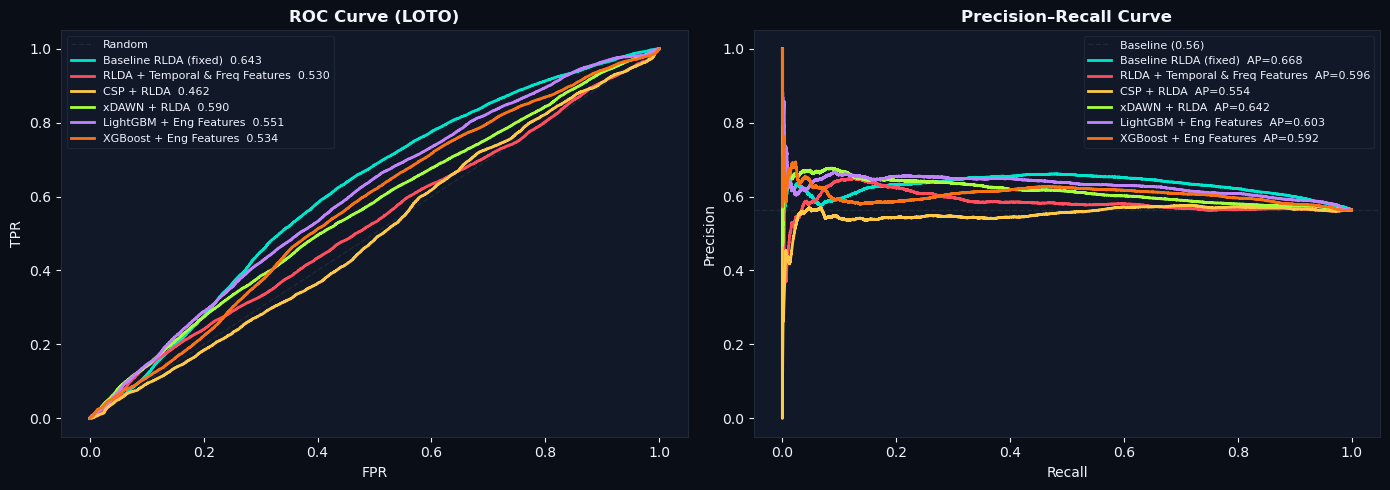

In [20]:
%matplotlib inline
os.makedirs("report", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
for ax in axes:
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    ax.tick_params(colors=WHITE)

ax_roc, ax_pr = axes
ax_roc.plot([0, 1], [0, 1], color=EDGE, lw=1, ls="--", label="Random")
ax_pr.axhline(
    y_all.mean(), color=EDGE, lw=1, ls="--", label=f"Baseline ({y_all.mean():.2f})"
)

for r, col in zip(all_results, PALETTE):
    fpr, tpr, _ = roc_curve(y_all, r["scores"])
    prec, rec, _ = precision_recall_curve(y_all, r["scores"])
    ax_roc.plot(fpr, tpr, lw=2, color=col, label=f"{r['label']}  {r['auc']:.3f}")
    ax_pr.plot(rec, prec, lw=2, color=col, label=f"{r['label']}  AP={r['ap']:.3f}")

for ax, xlabel, ylabel, title in [
    (ax_roc, "FPR", "TPR", "ROC Curve (LOTO)"),
    (ax_pr, "Recall", "Precision", "Precision–Recall Curve"),
]:
    ax.set_xlabel(xlabel, color=WHITE)
    ax.set_ylabel(ylabel, color=WHITE)
    ax.set_title(title, color=WHITE, fontweight="bold")
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)

plt.tight_layout()
plt.savefig(
    "report/pipeline_v2_curves.png", dpi=120, bbox_inches="tight", facecolor=DARK
)
plt.show()

## 15 · Per-Fold AUC & AP Distribution

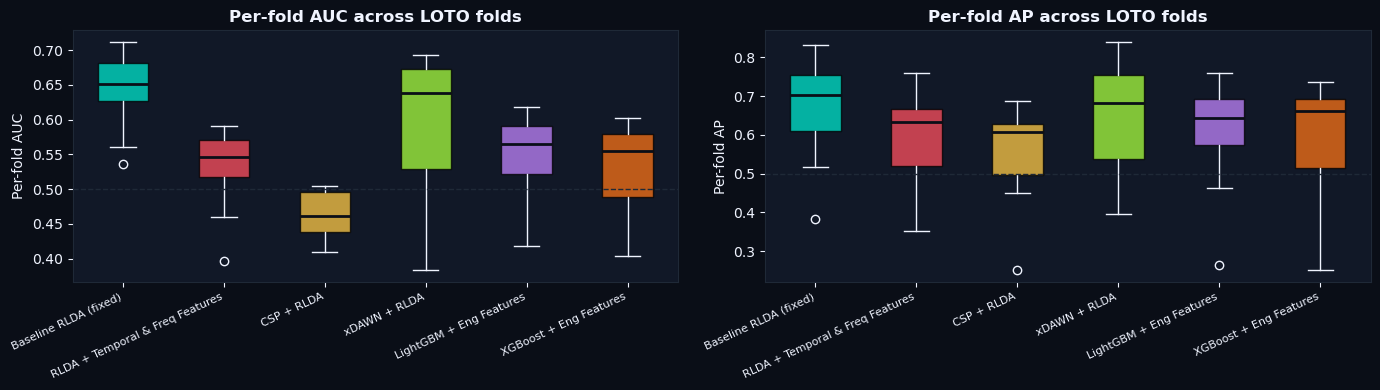

In [21]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=DARK)

for ax, metric, title in [
    (axes[0], "auc", "Per-fold AUC"),
    (axes[1], "ap", "Per-fold AP"),
]:
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    ax.tick_params(colors=WHITE)

    data = [[r[metric] for r in res["fold_results"]] for res in all_results]
    labels = [res["label"] for res in all_results]
    bp = ax.boxplot(
        data,
        patch_artist=True,
        notch=False,
        medianprops=dict(color=DARK, lw=2),
        whiskerprops=dict(color=WHITE),
        capprops=dict(color=WHITE),
        flierprops=dict(markeredgecolor=WHITE),
    )
    for patch, col in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(col)
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=25, ha="right", color=WHITE, fontsize=8)
    ax.set_ylabel(title, color=WHITE)
    ax.set_title(f"{title} across LOTO folds", color=WHITE, fontweight="bold")
    ax.axhline(0.5, color=EDGE, lw=1, ls="--")

plt.tight_layout()
plt.savefig(
    "report/pipeline_v2_boxplot.png", dpi=120, bbox_inches="tight", facecolor=DARK
)
plt.show()

## 16 · Event Sensitivity vs FA/min Trade-off

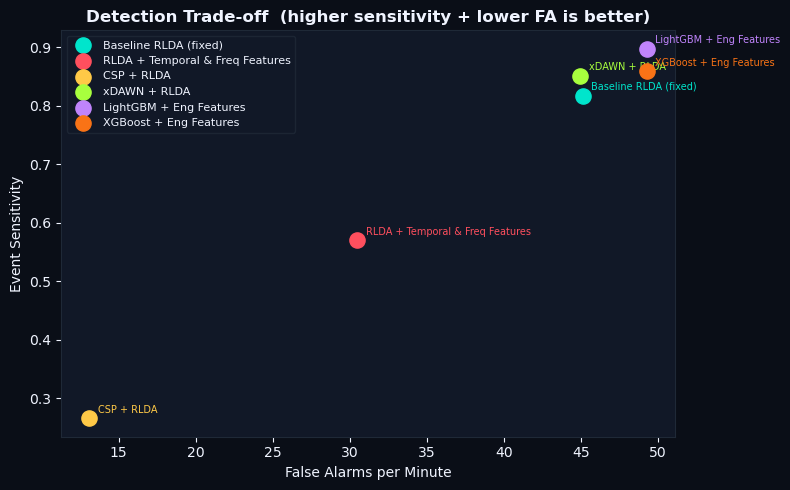

In [22]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(8, 5), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE)

for r, col in zip(all_results, PALETTE):
    e = r["evt"]
    ax.scatter(
        e["fa_per_minute"],
        e["event_sensitivity"],
        color=col,
        s=120,
        zorder=5,
        label=r["label"],
    )
    ax.annotate(
        r["label"],
        (e["fa_per_minute"], e["event_sensitivity"]),
        textcoords="offset points",
        xytext=(6, 4),
        color=col,
        fontsize=7,
    )

ax.set_xlabel("False Alarms per Minute", color=WHITE)
ax.set_ylabel("Event Sensitivity", color=WHITE)
ax.set_title(
    "Detection Trade-off  (higher sensitivity + lower FA is better)",
    color=WHITE,
    fontweight="bold",
)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
plt.tight_layout()
plt.savefig(
    "report/pipeline_v2_tradeoff.png", dpi=120, bbox_inches="tight", facecolor=DARK
)
plt.show()